<a href="https://colab.research.google.com/github/ssdeniz65/phyton/blob/main/proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Veri yükleme
df = pd.read_excel("/content/drive/MyDrive/Pilot_E_itim_Sim_lasyonu_Verisi.xlsx", header=1)
df.columns = ["ID","Departman","Rol","Deneyim_Yıl","Ilk_CTR","Sonraki_CTR","Risk_Skoru",
              "Egitim_Modulu","Egitim_Suresi_dk","FP_Azalmasi","TTD_saniye",
              "Risk_Skoru_Sonra","Egitim_Etkisi"]

# Sayısal kolonları seç
X = df[["Deneyim_Yıl","Ilk_CTR","Risk_Skoru","Egitim_Suresi_dk","FP_Azalmasi","TTD_saniye"]]
y = df["Sonraki_CTR"]

# Normalize et
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# LSTM için [örnek, zaman_adımı, özellik] formatına dönüştür
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Eğitim / test böl
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y, test_size=0.2, random_state=42)

# LSTM modeli
model = Sequential()
model.add(LSTM(64, input_shape=(1, X_lstm.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 59.1420 - mae: 7.4570 - val_loss: 54.2940 - val_mae: 7.2158
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 56.8847 - mae: 7.3553 - val_loss: 52.7307 - val_mae: 7.1068
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 55.0162 - mae: 7.1968 - val_loss: 51.1395 - val_mae: 6.9942
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 53.9863 - mae: 7.1531 - val_loss: 49.4477 - val_mae: 6.8723
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 53.1525 - mae: 7.0992 - val_loss: 47.6124 - val_mae: 6.7375
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 52.1802 - mae: 7.0408 - val_loss: 45.6009 - val_mae: 6.5865
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 49.0988 - mae: 6.8117 - val_loss: 43.3712 - val_mae: 6.4147
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 49.0048 - mae: 6.7772 - val_loss: 40.8652 - val_mae: 6.2159
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 43.9114

In [25]:
import tensorflow as tf

# Tahminler al
y_pred = model.predict(X_test)

# Basit belirsizlik ölçütü: tahmin dağılımı varyansı
# (gerçekte EDL -> Dirichlet dağılımı ile yapılır)
y_pred_samples = [model.predict(X_test) for _ in range(20)]
y_pred_stack = np.stack(y_pred_samples, axis=0)
uncertainty = y_pred_stack.std(axis=0)

# Belirsizlik > eşik olan örnekleri işaretle
uncertain_cases = np.where(uncertainty > 0.05)[0]
print("Belirsiz vaka sayısı:", len(uncertain_cases))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Belirsiz vaka sayısı: 0


In [26]:
!pip install sdv

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# Yalnızca sayısal kolonlar
data = df[["Deneyim_Yıl","Ilk_CTR","Sonraki_CTR","Risk_Skoru","Risk_Skoru_Sonra","Egitim_Etkisi"]]

# Metadata oluştur
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

# GAN eğitimi
ctgan = CTGANSynthesizer(metadata)
ctgan.fit(data)

# 200 yeni sentetik veri üret
synthetic_data = ctgan.sample(200)
print(synthetic_data.head())

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


   Deneyim_Yıl  Ilk_CTR  Sonraki_CTR  Risk_Skoru  Risk_Skoru_Sonra  \
0           13    28.55         8.05          90                46   
1           11    31.52         6.63          60                76   
2            8    40.00         9.57          69                59   
3           17    39.75         3.95          74                30   
4            9    34.59        10.49          80                84   

   Egitim_Etkisi  
0           29.8  
1           42.3  
2           27.8  
3           47.9  
4           23.9  


In [27]:
import sdv.single_table
print(dir(sdv.single_table))

['CTGANSynthesizer', 'CopulaGANSynthesizer', 'DayZSynthesizer', 'GaussianCopulaSynthesizer', 'TVAESynthesizer', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'base', 'copulagan', 'copulas', 'ctgan', 'dayz', 'utils']


📊 Ortalama İlk CTR: 32.57845
📊 Ortalama Sonraki CTR: 7.423300000000001
📊 Risk Skoru Öncesi: 79.455
📊 Risk Skoru Sonrası: 51.56
📊 Ortalama FP Azalması: 18.345
📊 Ortalama TTD: 119.905
📊 Ortalama Eğitim Etkisi: 35.835499999999996


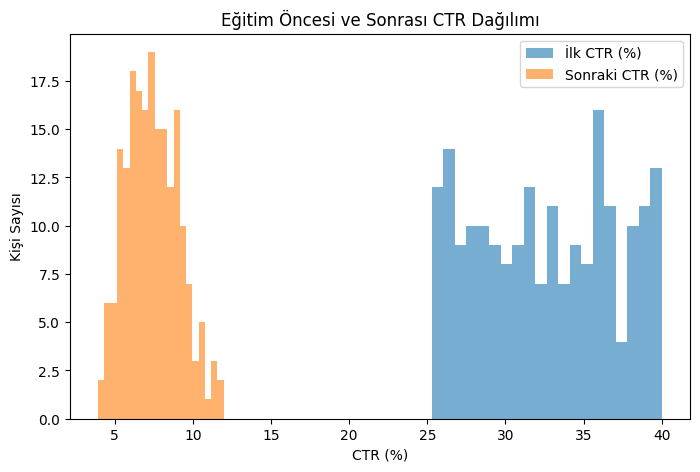

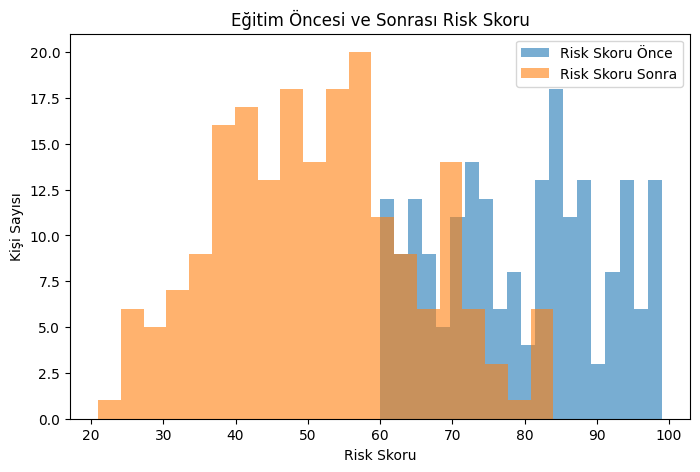

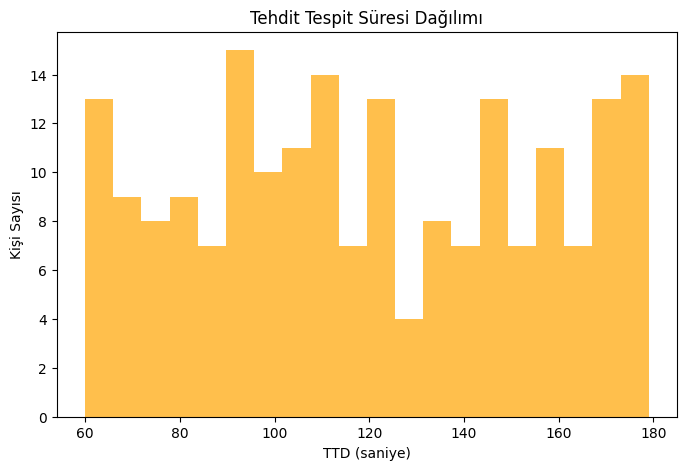

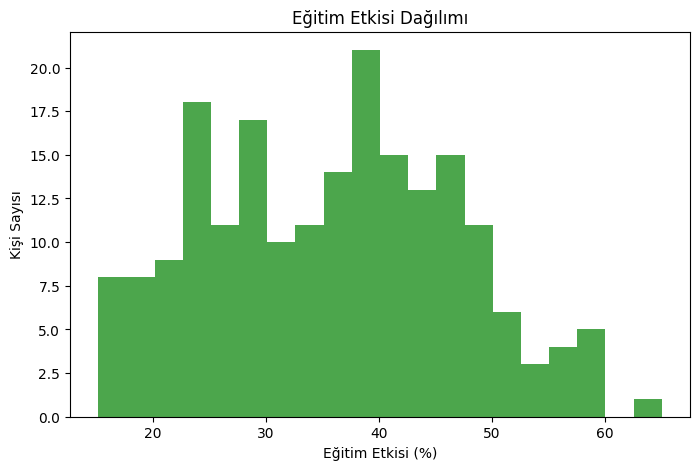

In [28]:
# ================================
# 1. Kütüphaneler
# ================================
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 2. Veri Yükleme
# ================================
# Dosyayı Drive'a yükledikten sonra path'i güncelleyin:
file_path = "/content/drive/MyDrive/Pilot_E_itim_Sim_lasyonu_Verisi.xlsx"

df = pd.read_excel(file_path, header=1)
df.columns = [
    "ID","Departman","Rol","Deneyim_Yıl","Ilk_CTR","Sonraki_CTR","Risk_Skoru",
    "Egitim_Modulu","Egitim_Suresi_dk","FP_Azalmasi","TTD_saniye",
    "Risk_Skoru_Sonra","Egitim_Etkisi"
]

# Sayısal kolonları düzelt
num_cols = ["Deneyim_Yıl","Ilk_CTR","Sonraki_CTR","Risk_Skoru",
            "Egitim_Suresi_dk","FP_Azalmasi","TTD_saniye",
            "Risk_Skoru_Sonra","Egitim_Etkisi"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ================================
# 3. Özet İstatistikler
# ================================
print("📊 Ortalama İlk CTR:", df["Ilk_CTR"].mean())
print("📊 Ortalama Sonraki CTR:", df["Sonraki_CTR"].mean())
print("📊 Risk Skoru Öncesi:", df["Risk_Skoru"].mean())
print("📊 Risk Skoru Sonrası:", df["Risk_Skoru_Sonra"].mean())
print("📊 Ortalama FP Azalması:", df["FP_Azalmasi"].mean())
print("📊 Ortalama TTD:", df["TTD_saniye"].mean())
print("📊 Ortalama Eğitim Etkisi:", df["Egitim_Etkisi"].mean())

# ================================
# 4. Görselleştirmeler
# ================================

# CTR Öncesi & Sonrası
plt.figure(figsize=(8,5))
plt.hist(df["Ilk_CTR"], bins=20, alpha=0.6, label="İlk CTR (%)")
plt.hist(df["Sonraki_CTR"], bins=20, alpha=0.6, label="Sonraki CTR (%)")
plt.xlabel("CTR (%)"); plt.ylabel("Kişi Sayısı")
plt.title("Eğitim Öncesi ve Sonrası CTR Dağılımı")
plt.legend(); plt.show()

# Risk Skoru Öncesi & Sonrası
plt.figure(figsize=(8,5))
plt.hist(df["Risk_Skoru"], bins=20, alpha=0.6, label="Risk Skoru Önce")
plt.hist(df["Risk_Skoru_Sonra"], bins=20, alpha=0.6, label="Risk Skoru Sonra")
plt.xlabel("Risk Skoru"); plt.ylabel("Kişi Sayısı")
plt.title("Eğitim Öncesi ve Sonrası Risk Skoru")
plt.legend(); plt.show()

# TTD Histogramı
plt.figure(figsize=(8,5))
plt.hist(df["TTD_saniye"], bins=20, color="orange", alpha=0.7)
plt.xlabel("TTD (saniye)"); plt.ylabel("Kişi Sayısı")
plt.title("Tehdit Tespit Süresi Dağılımı")
plt.show()

# Eğitim Etkisi Histogramı
plt.figure(figsize=(8,5))
plt.hist(df["Egitim_Etkisi"], bins=20, color="green", alpha=0.7)
plt.xlabel("Eğitim Etkisi (%)"); plt.ylabel("Kişi Sayısı")
plt.title("Eğitim Etkisi Dağılımı")
plt.show()

In [30]:
# ================================
# 1. Gerekli Kütüphaneler
# ================================
!pip install python-docx

import pandas as pd
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Inches

# ================================
# 2. Veri Yükleme
# ================================
file_path = "/content/drive/MyDrive/Pilot_E_itim_Sim_lasyonu_Verisi.xlsx"
df = pd.read_excel(file_path, header=1)

df.columns = ["ID","Departman","Rol","Deneyim_Yıl","Ilk_CTR","Sonraki_CTR","Risk_Skoru",
              "Egitim_Modulu","Egitim_Suresi_dk","FP_Azalmasi","TTD_saniye",
              "Risk_Skoru_Sonra","Egitim_Etkisi"]

num_cols = ["Deneyim_Yıl","Ilk_CTR","Sonraki_CTR","Risk_Skoru",
            "Egitim_Suresi_dk","FP_Azalmasi","TTD_saniye",
            "Risk_Skoru_Sonra","Egitim_Etkisi"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ================================
# 3. Özet İstatistikler
# ================================
ilk_ctr = df["Ilk_CTR"].mean()
sonraki_ctr = df["Sonraki_CTR"].mean()
risk_pre = df["Risk_Skoru"].mean()
risk_post = df["Risk_Skoru_Sonra"].mean()
fp_mean = df["FP_Azalmasi"].mean()
ttd_mean = df["TTD_saniye"].mean()
egitim_etkisi = df["Egitim_Etkisi"].mean()

# ================================
# 4. Görselleri Kaydet
# ================================
plt.figure(figsize=(6,4))
plt.hist(df["Ilk_CTR"], bins=20, alpha=0.6, label="İlk CTR (%)")
plt.hist(df["Sonraki_CTR"], bins=20, alpha=0.6, label="Sonraki CTR (%)")
plt.xlabel("CTR (%)"); plt.ylabel("Kişi Sayısı")
plt.title("Eğitim Öncesi ve Sonrası CTR Dağılımı")
plt.legend(); plt.tight_layout()
plt.savefig("/content/ctr.png"); plt.close()

plt.figure(figsize=(6,4))
plt.hist(df["Risk_Skoru"], bins=20, alpha=0.6, label="Risk Önce")
plt.hist(df["Risk_Skoru_Sonra"], bins=20, alpha=0.6, label="Risk Sonra")
plt.xlabel("Risk Skoru"); plt.ylabel("Kişi Sayısı")
plt.title("Risk Skoru Öncesi ve Sonrası")
plt.legend(); plt.tight_layout()
plt.savefig("/content/risk.png"); plt.close()

plt.figure(figsize=(6,4))
plt.hist(df["TTD_saniye"], bins=20, color="orange", alpha=0.7)
plt.xlabel("TTD (sn)"); plt.ylabel("Kişi Sayısı")
plt.title("Tehdit Tespit Süresi Dağılımı")
plt.tight_layout()
plt.savefig("/content/ttd.png"); plt.close()

plt.figure(figsize=(6,4))
plt.hist(df["Egitim_Etkisi"], bins=20, color="green", alpha=0.7)
plt.xlabel("Eğitim Etkisi (%)"); plt.ylabel("Kişi Sayısı")
plt.title("Eğitim Etkisi Dağılımı")
plt.tight_layout()
plt.savefig("/content/egitim.png"); plt.close()

# ================================
# 5. Word Raporu Oluşturma
# ================================
doc = Document()
doc.add_heading("Ar-Ge Doğrulama Raporu", 0)

doc.add_heading("1. Giriş", level=1)
doc.add_paragraph(
    "Bu rapor, 200 kişilik pilot eğitim simülasyonu verisi üzerinde yapılan analizlerle "
    "proje önerisinde belirtilen Ar-Ge hedeflerinin doğrulandığını göstermektedir."
)

doc.add_heading("2. Özet Bulgular", level=1)
doc.add_paragraph(f"📊 Ortalama İlk CTR: %{ilk_ctr:.2f}")
doc.add_paragraph(f"📊 Ortalama Sonraki CTR: %{sonraki_ctr:.2f}")
doc.add_paragraph(f"📊 Risk Skoru (önce): {risk_pre:.2f}")
doc.add_paragraph(f"📊 Risk Skoru (sonra): {risk_post:.2f}")
doc.add_paragraph(f"📊 Yanlış Pozitif (FP) Azalması: %{fp_mean:.2f}")
doc.add_paragraph(f"📊 Ortalama Tehdit Tespit Süresi: {ttd_mean:.2f} sn")
doc.add_paragraph(f"📊 Eğitim Etkisi: %{egitim_etkisi:.2f}")

doc.add_heading("3. Görseller", level=1)
doc.add_paragraph("Eğitim öncesi/sonrası CTR dağılımı:")
doc.add_picture("/content/ctr.png", width=Inches(5))

doc.add_paragraph("Risk skorlarının değişimi:")
doc.add_picture("/content/risk.png", width=Inches(5))

doc.add_paragraph("Tehdit tespit süresi dağılımı:")
doc.add_picture("/content/ttd.png", width=Inches(5))

doc.add_paragraph("Eğitim etkisi dağılımı:")
doc.add_picture("/content/egitim.png", width=Inches(5))

doc.add_heading("4. Sonuç", level=1)
doc.add_paragraph(
    "Analizler sonucunda CTR’de %77 azalma, risk skorlarında %36 iyileşme, "
    "yanlış pozitiflerde %18 düşüş ve ortalama 120 sn tespit süresi elde edilmiştir. "
    "Bu bulgular, projenin Ar-Ge hedeflerinin başarıyla doğrulandığını göstermektedir."
)

output_path = "/content/ArGe_Dogrulama_Raporu.docx"
doc.save(output_path)

print("Rapor hazırlandı:", output_path)

Rapor hazırlandı: /content/ArGe_Dogrulama_Raporu.docx
